# **Predicción de demanda en sector retail: Estudio compararativo de métodos globales y jerarquía temporal**

## **Extra - Importancia de variables de TFT**

Inés Umpiérrez Martínez

## **1. Carga de datos**

In [ ]:
# Instalar librerías
!pip install -q pytorch-forecasting pytorch-lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.7 MB/s eta 0:00:00


In [ ]:
# Importar librerías
from google.colab import drive
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
import warnings

In [ ]:
# Conectarse a Drive
drive.mount('/content/drive')

# Definir la ruta_output donde están guardados los datos
ruta_input = '/content/drive/My Drive/TFM Final/Datos/Input_Importancia_Variables'

# Definir la ruta_output donde se exportarán los datos
ruta_output = '/content/drive/My Drive/TFM Final/Datos/Output'

Mounted at /content/drive


In [ ]:
# Cargar las tablas
daily_df_tft = pd.read_csv(os.path.join(ruta_input, 'daily_df_tft.csv'), sep=';', decimal=',')
weekly_df_tft = pd.read_csv(os.path.join(ruta_input, 'weekly_df_tft.csv'), sep=';', decimal=',')

## **2. Modelado y extracción de interpretabilidad**

### **2.1. Serie diaria - TFT**

In [ ]:
# Imprimir dataset
daily_df_tft

,unique_id,ds,y,product_category_name,product_name_lenght_esc,product_description_lenght_esc,product_photos_qty_esc,product_volume_esc,product_weight_esc,median_price_esc,cos_dow,sin_dow,cos_doy,sin_doy,is_weekend,is_month_start,is_month_end,is_national_holiday,is_black_friday
0,ac6c3623068f30de03045865e4e10089,2017-01-09,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,1.000000,0.000000,0.988039,0.154204,0,0,0,0,0
1,ac6c3623068f30de03045865e4e10089,2017-01-10,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,0.623490,0.781831,0.985240,0.171177,0,0,0,0,0
2,ac6c3623068f30de03045865e4e10089,2017-01-11,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,-0.222521,0.974928,0.982150,0.188099,0,0,0,0,0
3,ac6c3623068f30de03045865e4e10089,2017-01-12,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,-0.900969,0.433884,0.978769,0.204966,0,0,0,0,0
4,ac6c3623068f30de03045865e4e10089,2017-01-13,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,-0.900969,-0.433884,0.975099,0.221772,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699127,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-15,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,-0.222521,0.974928,-0.722519,-0.691351,0,0,0,0,0
699128,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-16,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,-0.900969,0.433884,-0.710520,-0.703677,0,0,0,0,0
699129,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-17,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,-0.900969,-0.433884,-0.698310,-0.715795,0,0,0,0,0
699130,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-18,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,-0.222521,-0.974928,-0.685894,-0.727701,1,0,0,0,0


In [ ]:
# Ignorar los warnings de Scikit-Learn
warnings.filterwarnings("ignore", message="X does not have valid feature names")

# Fijar semilla para garantizar reproducibilidad
pl.seed_everything(35)

# =========================================================
# PREPROCESAMIENTO DEL DATASET
# =========================================================

df = daily_df_tft.copy()
df['ds'] = pd.to_datetime(df['ds'])

# # Crear índice de tiempo secuencial (días)
df = df.sort_values(['unique_id', 'ds'])
df['time_idx'] = df.groupby('unique_id').cumcount()

# # Asignar tipado correcto a las variables
df['product_category_name'] = df['product_category_name'].astype(str)
df['unique_id'] = df['unique_id'].astype(str)

flags = ['is_weekend', 'is_month_start', 'is_month_end', 'is_national_holiday', 'is_black_friday']
for col in flags:
    df[col] = df[col].astype(int).astype(str)

df['y'] = df['y'].astype(float)
reales = ['product_name_lenght_esc', 'product_description_lenght_esc',
          'product_photos_qty_esc', 'product_volume_esc', 'product_weight_esc',
          'median_price_esc', 'cos_dow', 'sin_dow', 'cos_doy', 'sin_doy']
for col in reales:
    df[col] = df[col].astype(float)

INFO: Seed set to 35
INFO:lightning.fabric.utilities.seed:Seed set to 35


In [ ]:
# =========================================================
# DEFINICIÓN DE HIPERPARÁMETROS DEL MODELO
# =========================================================
max_encoder_length = 56
max_prediction_length = 14
batch_size = 64

training_cutoff = df["time_idx"].max() - max_prediction_length

training_dataset = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="y",
    group_ids=["unique_id"],
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,

    # Variables estáticas
    static_categoricals=["unique_id", "product_category_name"],
    static_reals=['product_name_lenght_esc', 'product_description_lenght_esc',
                  'product_photos_qty_esc', 'product_volume_esc',
                  'product_weight_esc', 'median_price_esc'],

    # Variables dinámicas conocidas
    time_varying_known_categoricals=['is_weekend', 'is_month_start', 'is_month_end',
                                     'is_national_holiday', 'is_black_friday'],
    time_varying_known_reals=['time_idx', 'cos_dow', 'sin_dow', 'cos_doy', 'sin_doy'],

    # Variables dinámicas desconocidas
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=["y"],

    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

train_dataloader = training_dataset.to_dataloader(train=True, batch_size=batch_size, num_workers=0)

In [ ]:
# =========================================================
# ENTRENAMIENTO DEL MODELO GEMELO
# =========================================================

# Configuración del trainer
trainer = pl.Trainer(
    max_steps=1000,
    accelerator="auto",
    enable_model_summary=True,
    enable_progress_bar=True,
    logger=False,
    enable_checkpointing=False
)

# Instanciar el modelo
tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=0.0032138545457220135,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=32,
    output_size=7,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=4,
)

# Entrenar el modelo
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperpara

Entrenando TFT Gemelo para extraer importancias...


INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │ 76.9 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.0 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 65.4 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 52.1 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 44.6 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 446 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 446 K                                                                                                
Total estimated model params size (MB): 1.784                                                                      
Modules in train mode: 539                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
INFO: `Trainer.fit` stopped: `max_steps=1000` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


¡Entrenamiento finalizado!


Creando muestra representativa (por SKU) para la gráfica...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Calculando importancias globales en GPU...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Generando gráficos...


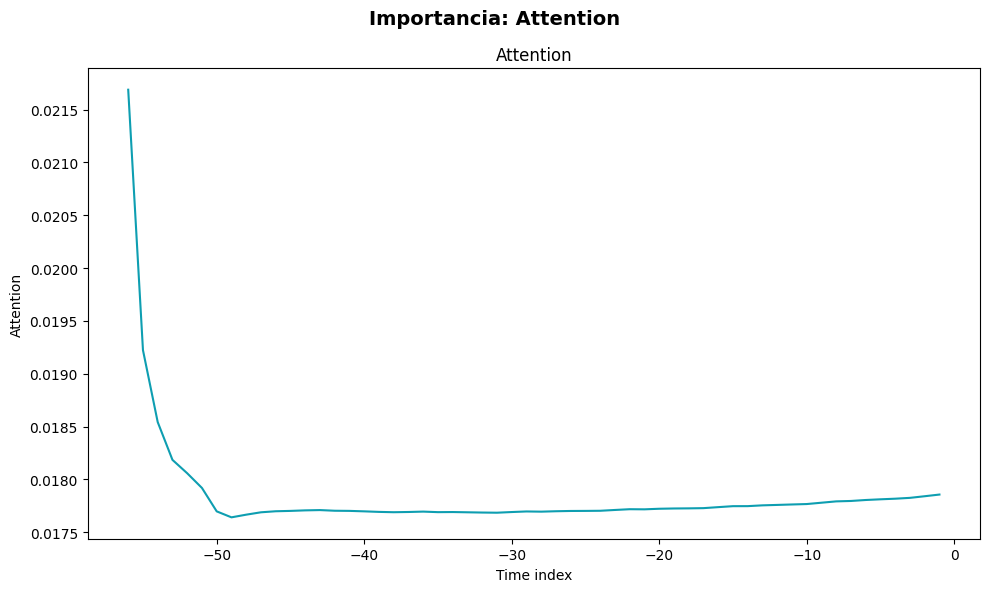

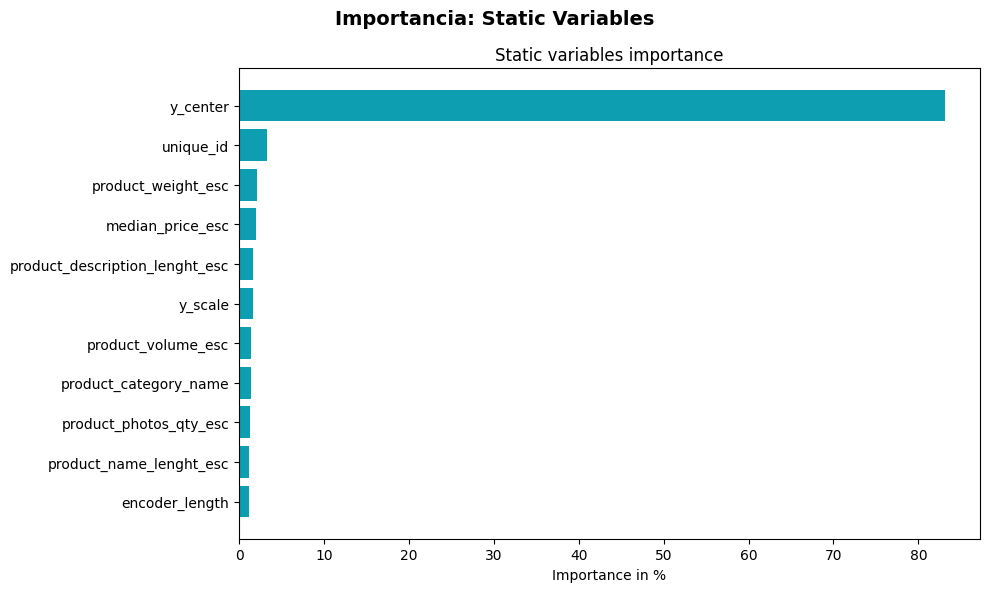

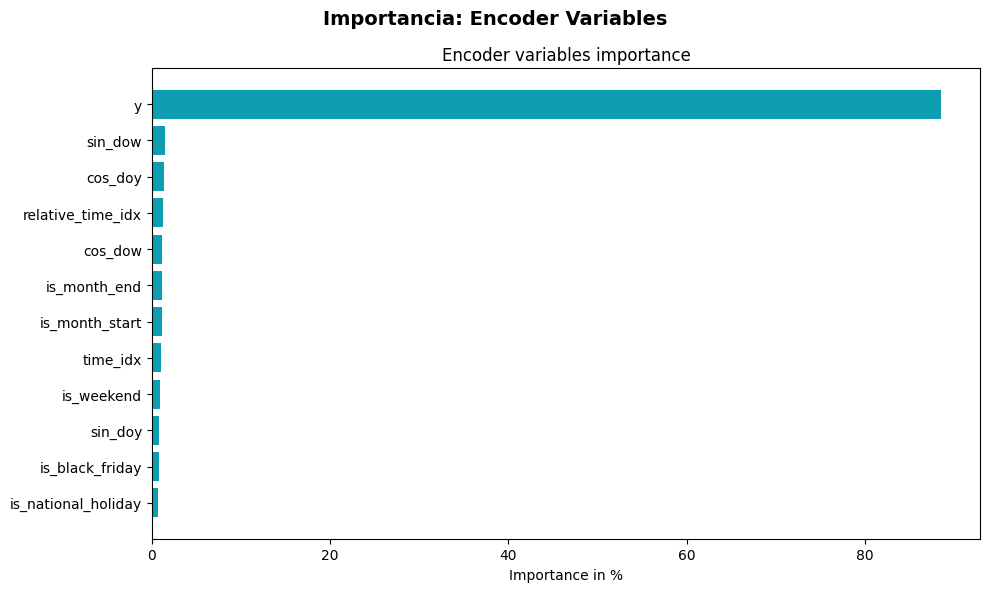

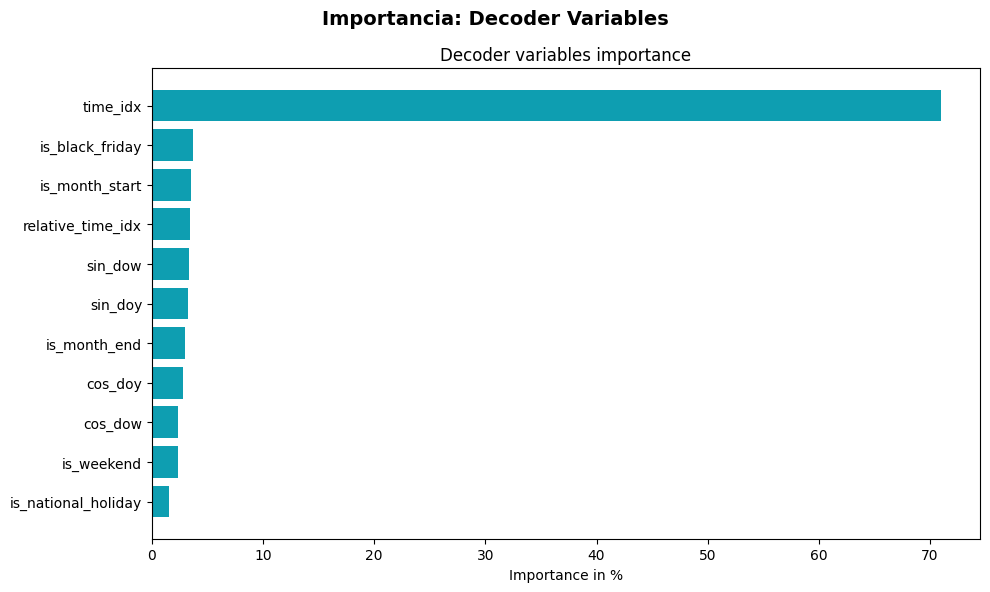

In [ ]:
# =========================================================
# EXTRACCIÓN DE IMPORTANCIA DE VARIABLES
# =========================================================

# Fijar semilla para garantizar reproducibilidad
np.random.seed(35)

# Obtener todos los productos únicos
productos_unicos = df['unique_id'].unique()

# Debido al alto coste computacional, se selecciona una muestra aleatoria del 30% del catálago de productos
n_skus = max(1, int(len(productos_unicos) * 0.30))
productos_muestra = np.random.choice(productos_unicos, size=n_skus, replace=False)

# Filtrado del dataframe
df_reducido = df[df['unique_id'].isin(productos_muestra)].copy()

# Extraer la interpretabilidad
dataset_grafico = TimeSeriesDataSet.from_dataset(training_dataset, df_reducido)
dataloader_grafico = dataset_grafico.to_dataloader(train=False, batch_size=512, num_workers=2)
interpretation = tft.interpret_output(
    tft.predict(dataloader_grafico, mode="raw", return_x=False),
    reduction="sum"
)


# =========================================================
# GENERACIÓN DE GRÁFICOS
# =========================================================

with plt.rc_context({'axes.prop_cycle': plt.cycler(color=['#0E9EB1'])}):

    figuras = tft.plot_interpretation(interpretation)

    for nombre, figura in figuras.items():
        titulo = nombre.replace('_', ' ').title()
        figura.suptitle(f"Importancia: {titulo}", fontsize=14, fontweight='bold')
        figura.set_size_inches(10, 6)
        figura.tight_layout()
        figura.show()

### **2.2. Serie semanal - TFT**

In [ ]:
# Imprimir el dataset
weekly_df_tft

,unique_id,ds,y,product_category_name,product_name_lenght_esc,product_description_lenght_esc,product_photos_qty_esc,product_volume_esc,product_weight_esc,median_price_esc,sin_woy,cos_woy,is_month_start_week,is_month_end_week,national_holidays_count,is_black_friday_week
0,ac6c3623068f30de03045865e4e10089,2017-01-09,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,0.238517,0.971138,0,0,0,0
1,ac6c3623068f30de03045865e4e10089,2017-01-16,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,0.353452,0.935453,0,0,0,0
2,ac6c3623068f30de03045865e4e10089,2017-01-23,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,0.463267,0.886219,0,0,0,0
3,ac6c3623068f30de03045865e4e10089,2017-01-30,1,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,0.566372,0.824150,1,1,0,0
4,ac6c3623068f30de03045865e4e10089,2017-02-06,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,0.661275,0.750144,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99871,4cafc445fc7535c3b41b8978c0ce68dc,2018-07-16,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,-0.343434,-0.939177,0,0,0,0
99872,4cafc445fc7535c3b41b8978c0ce68dc,2018-07-23,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,-0.453769,-0.891119,0,0,0,0
99873,4cafc445fc7535c3b41b8978c0ce68dc,2018-07-30,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,-0.557532,-0.830155,1,1,0,0
99874,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-06,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,-0.653220,-0.757168,0,0,0,0


In [ ]:
# Ignorar warnings de Scikit-Learn
warnings.filterwarnings("ignore", message="X does not have valid feature names")

# Fijar semilla para garantizar reproducibilidad
pl.seed_everything(35)

# =========================================================
# PREPROCESAMIENTO DEL DATASET
# =========================================================
df_week = weekly_df_tft.copy()
df_week['ds'] = pd.to_datetime(df_week['ds'])

# Crear índice de tiempo secuencial (semanas)
df_week = df_week.sort_values(['unique_id', 'ds'])
df_week['time_idx'] = df_week.groupby('unique_id').cumcount()

# Asignar tipado correcto a las variables
df_week['product_category_name'] = df_week['product_category_name'].astype(str)
df_week['unique_id'] = df_week['unique_id'].astype(str)

flags_semanales = ['is_month_start_week', 'is_month_end_week', 'is_black_friday_week']
for col in flags_semanales:
    df_week[col] = df_week[col].astype(int).astype(str)

reales_semanales = [
    'product_name_lenght_esc', 'product_description_lenght_esc',
    'product_photos_qty_esc', 'product_volume_esc', 'product_weight_esc',
    'median_price_esc', 'sin_woy', 'cos_woy', 'national_holidays_count'
]
df_week['y'] = df_week['y'].astype(float)
for col in reales_semanales:
    df_week[col] = df_week[col].astype(float)

# =========================================================
# DEFINICIÓN DE HIPERPARÁMETROS DEL MODELO
# =========================================================
max_encoder_length = 12
max_prediction_length = 2
batch_size = 64
training_cutoff = df_week["time_idx"].max() - max_prediction_length

training_dataset_week = TimeSeriesDataSet(
    df_week[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="y",
    group_ids=["unique_id"],
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,

    # Variables estáticas
    static_categoricals=["unique_id", "product_category_name"],
    static_reals=[
        'product_name_lenght_esc', 'product_description_lenght_esc',
        'product_photos_qty_esc', 'product_volume_esc',
        'product_weight_esc', 'median_price_esc'
    ],

    # Variables dinámicas conocidas
    time_varying_known_categoricals=flags_semanales,
    time_varying_known_reals=['time_idx', 'sin_woy', 'cos_woy', 'national_holidays_count'],

    # Variables dinámicas desconocidas
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=["y"],

    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

train_dataloader_week = training_dataset_week.to_dataloader(train=True, batch_size=batch_size, num_workers=0)


# =========================================================
# ENTRENAMIENTO DEL MODELO GEMELO
# =========================================================

# Configuración del trainer
trainer = pl.Trainer(
    max_steps=1000,
    accelerator="auto",
    enable_model_summary=True,
    enable_progress_bar=True,
    logger=False,
    enable_checkpointing=False
)

# Instanciar el modelo
tft_week = TemporalFusionTransformer.from_dataset(
    training_dataset_week,
    learning_rate=0.0032138545457220135,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=32,
    output_size=7,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=4,
)

# Entrenar el modelo
trainer.fit(tft_week, train_dataloaders=train_dataloader_week)


INFO: Seed set to 35
INFO:lightning.fabric.utilities.seed:Seed set to 35
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during c

Entrenando TFT Gemelo Semanal...


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │ 76.9 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    960 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 65.4 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 43.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 36.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 429 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 429 K                                                                                                
Total estimated model params size (MB): 1.717                                                                      
Modules in train mode: 492                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
INFO: `Trainer.fit` stopped: `max_steps=1000` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


Creando muestra representativa (por SKU) para la gráfica...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Calculando importancias globales...


/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Generando gráficos semanales...


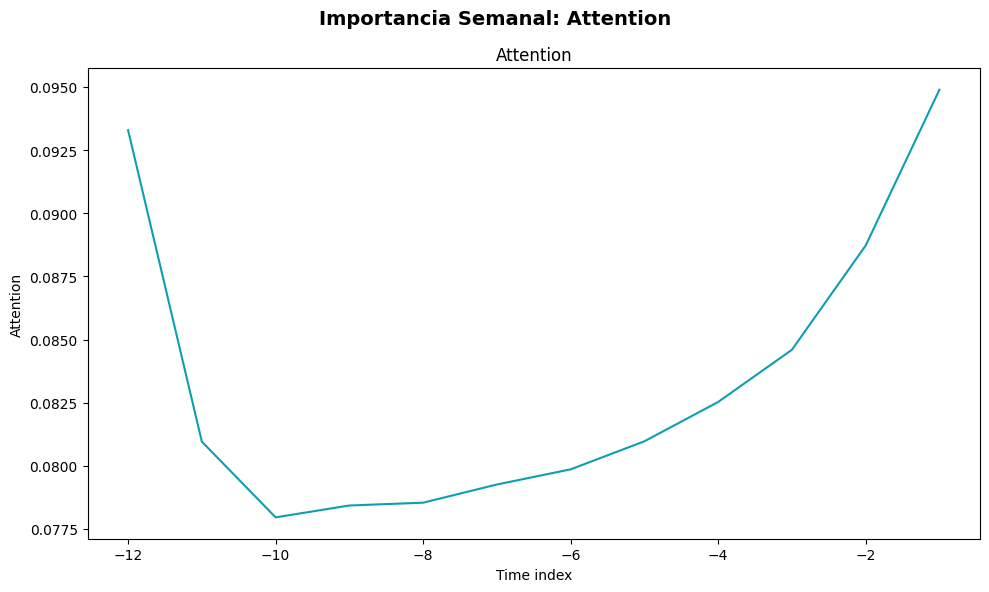

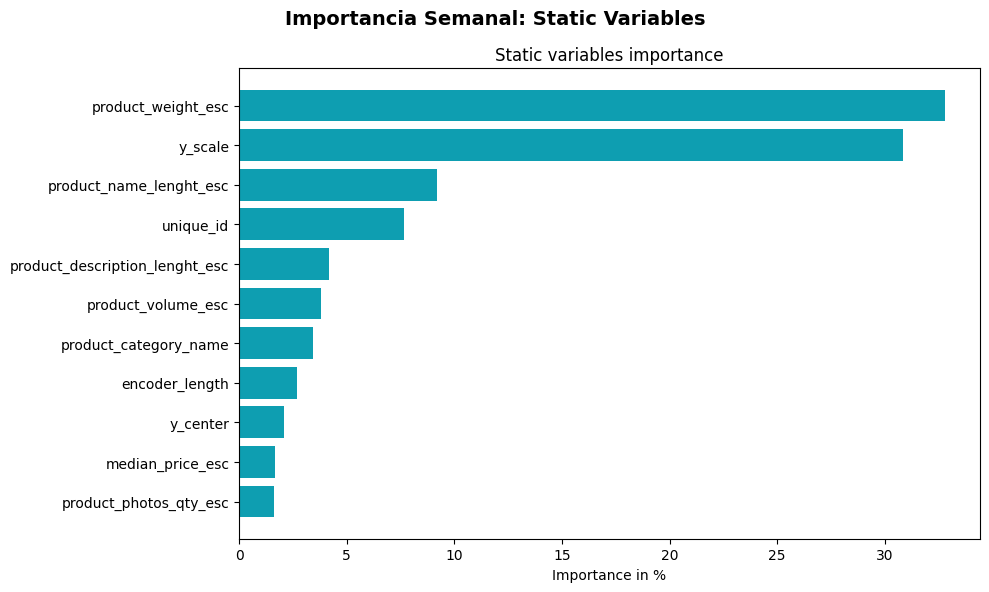

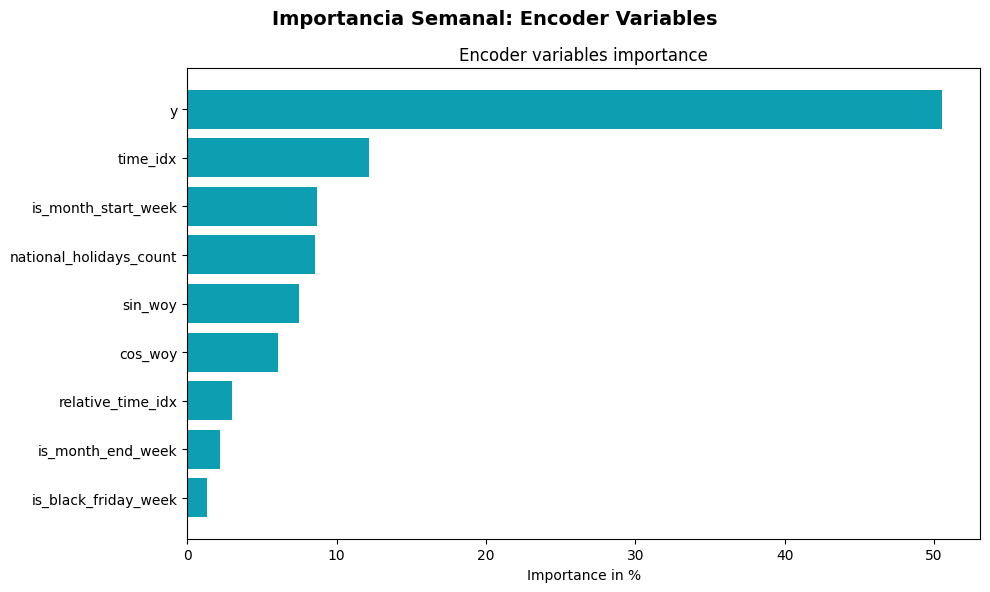

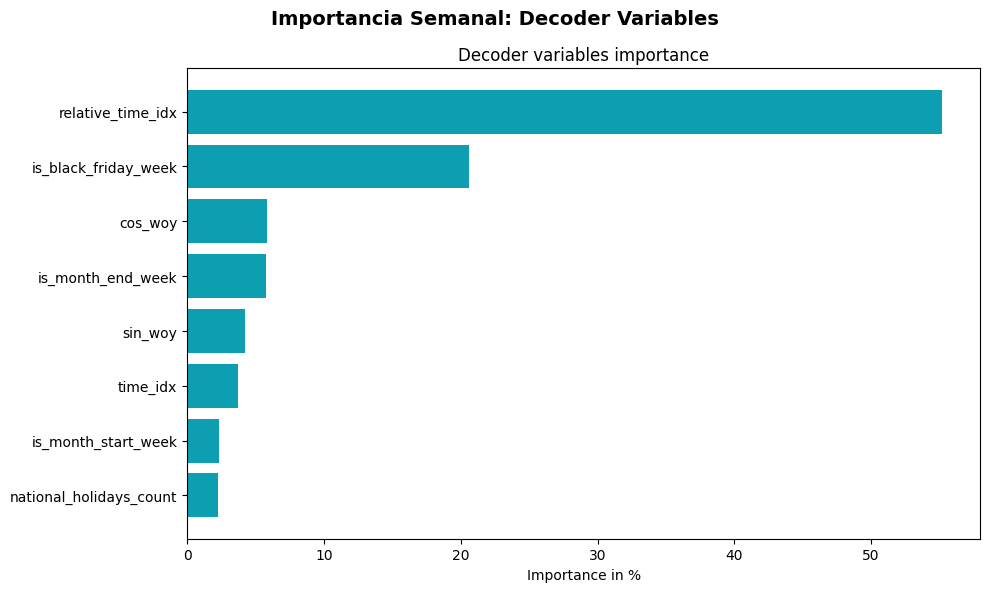

In [ ]:
# =========================================================
# EXTRACCIÓN DE IMPORTANCIA DE VARIABLES
# =========================================================

# Fijar semilla para garantizar reproducibilidad
np.random.seed(35)

# Obtener todos los productos únicos
productos_unicos_week = df_week['unique_id'].unique()

# Al ser datos semanales (mucho menos volumen), se coge el 100% del catálogo, no se coge una muestra
n_skus_week = max(1, int(len(productos_unicos_week) * 1))
productos_muestra_week = np.random.choice(productos_unicos_week, size=n_skus_week, replace=False)
df_reducido_week = df_week[df_week['unique_id'].isin(productos_muestra_week)].copy()

# Extraer interpretabilidad
dataset_grafico_week = TimeSeriesDataSet.from_dataset(training_dataset_week, df_reducido_week)
dataloader_grafico_week = dataset_grafico_week.to_dataloader(train=False, batch_size=512, num_workers=2)
interpretation_week = tft_week.interpret_output(
    tft_week.predict(dataloader_grafico_week, mode="raw", return_x=False),
    reduction="sum"
)


# =========================================================
# GENERACIÓN DE GRÁFICOS
# =========================================================
with plt.rc_context({'axes.prop_cycle': plt.cycler(color=['#0E9EB1'])}):
    figuras_week = tft_week.plot_interpretation(interpretation_week)

    for nombre, figura in figuras_week.items():
        titulo = nombre.replace('_', ' ').title()
        figura.suptitle(f"Importancia Semanal: {titulo}", fontsize=14, fontweight='bold')
        figura.set_size_inches(10, 6)
        figura.tight_layout()
        figura.show()